In [29]:
gdf.total_bounds

array([ 692405.38806786, 6166404.72204552,  695692.80139188,
       6169030.62220711])

   Zone key  Year                Type   ID  \
0         Y  2025           Volunteer    0   
1         Y  2025           Volunteer    1   
2         Y  2025           Volunteer    2   
3         Y  2025           Volunteer    3   
4         Z  2025           Volunteer    4   
..      ...   ...                 ...  ...   
88     Park  2025    Park_n_pay_south  109   
89     Park  2025     Park_n_pay_west  110   
90        R  2025          Restricted  113   
91     Park  2025  Restricted_parking  114   
92        R  2025      Restricted_HHX  114   

                                             geometry  
0   POLYGON ((692687.648 6168230.957, 692686.594 6...  
1   POLYGON ((692712.584 6168110.94, 692847.84 616...  
2   POLYGON ((692707.124 6167955.527, 692849.162 6...  
3   POLYGON ((692686.601 6167807.271, 692841.473 6...  
4   POLYGON ((692870.122 6167766.292, 692873.116 6...  
..                                                ...  
88  POLYGON ((695135.564 6166549.898, 694878.353 6...  

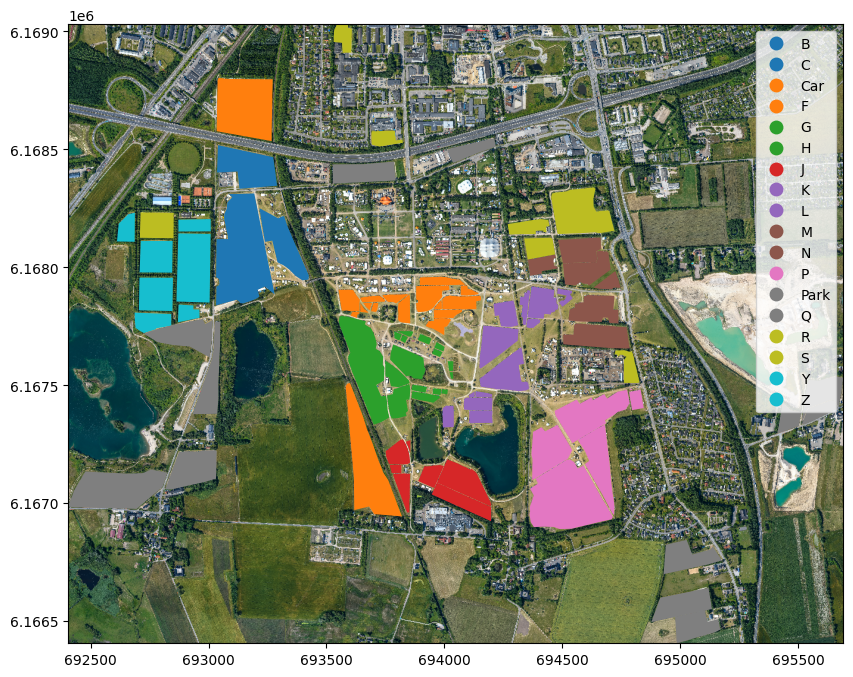

In [ ]:
import matplotlib.pyplot as plt 
import geopandas as gpd 
import rasterio 
from rasterio.plot import show 
from rasterio.windows import from_bounds 
from affine import Affine #src: rasterio/affine

with rasterio.open('../data/2025-07-02-Roskilde-Festival_20cm.tif') as src:
    raster_crs = src.crs 
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf = gpd.read_file("../data/camping_zones.shp")
    gdf = gdf.to_crs(raster_crs)
    print(gdf)
    minx, miny, maxx, maxy = gdf.total_bounds
 
    window = from_bounds(minx,miny,maxx,maxy, transform=src.transform) #left, bottom, right, top
    pix_res = 1024
    data = src.read(window=window,out_shape=(src.count, pix_res, pix_res)) #reads raster with downsampling

    transform = src.window_transform(window)
    scale_x = window.width / pix_res #transform coordinates to fit gdf window (downsampling makes each pixel cover a larger area)
    scale_y = window.height / pix_res #transform coordinates to fit gdf window
    
    # Adjust transform
    new_transform = transform * Affine.scale(scale_x, scale_y) #scale up each coordinate in the raster to match the larger area due to downsampling

    show(data, transform=new_transform, ax=ax)
    gdf.plot(column="Zone key", legend=True, ax=ax) 
    plt.show()
    






In [31]:
for i in range(10):
    print(f"{i:06d}")

000000
000001
000002
000003
000004
000005
000006
000007
000008
000009


In [38]:
merged_zones.index

Index(['B', 'C', 'Car', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Park',
       'Q', 'R', 'S', 'Y', 'Z'],
      dtype='str', name='Zone key')

                                                   geometry  Year  \
Zone key                                                            
B         POLYGON ((693040.291 6168517.684, 693274.523 6...  2025   
C         MULTIPOLYGON (((693280.439 6167884.483, 693238...  2025   
Car       MULTIPOLYGON (((693600.104 6167508.631, 693655...  2025   
F         MULTIPOLYGON (((693640.716 6167810.032, 693639...  2025   
G         MULTIPOLYGON (((693785.89 6167482.089, 693810....  2025   
H         MULTIPOLYGON (((694028.295 6167526.931, 694022...  2025   
J         MULTIPOLYGON (((693979.496 6167081.165, 694020...  2025   
K         MULTIPOLYGON (((694175.231 6167392.015, 694203...  2025   
L         MULTIPOLYGON (((694264.274 6167615.512, 694326...  2025   
M         MULTIPOLYGON (((694740.196 6167943.676, 694747...  2025   
N         MULTIPOLYGON (((694504.666 6167714.401, 694548...  2025   
P         MULTIPOLYGON (((694536.695 6167182.553, 694550...  2025   
Park      MULTIPOLYGON (((695120.6

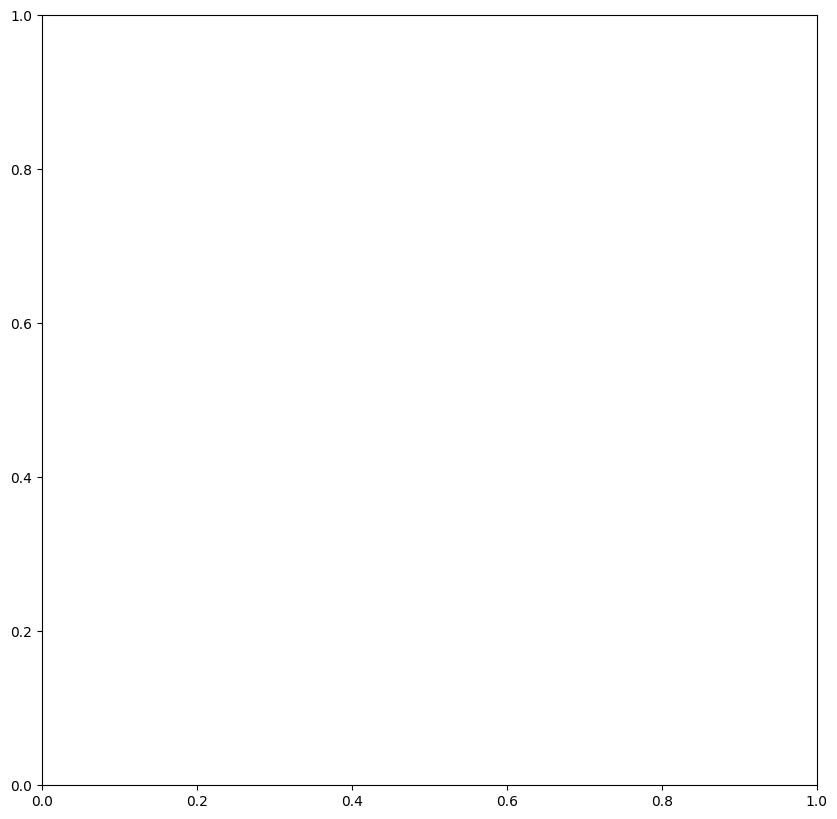

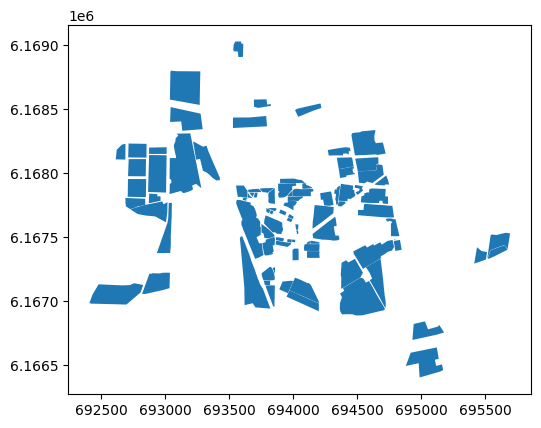

In [ ]:
from rasterio import windows 
from shapely.geometry import box 
import numpy as np 
import json 
import os 
from PIL import Image 


im_out_dir = os.path.join("data","tiles")
metadata_out_dir = os.path.join("data","metadata")

if not os.path.exists(im_out_dir):
    os.makedirs(im_out_dir,exist_ok=True)

if not os.path.exists(metadata_out_dir):
    os.makedirs(metadata_out_dir,exist_ok=True)


im_size = (128,128)
overlap = 24
stride = im_size[0]-overlap
#coord_slice = (im_size[0]/)
with rasterio.open('../data/2025-07-02-Roskilde-Festival_20cm.tif') as src:
    raster_crs = src.crs 
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf = gpd.read_file("../data/camping_zones.shp")
    gdf = gdf.to_crs(raster_crs)
    unique_zones = gdf["Zone key"].unique()
    merged_zones = gdf.dissolve(by="Zone key")
    print(merged_zones)
    merged_zones.plot(legend=True)
    plt.show()
    records = []
    for i, (zone_pol, zone_key) in enumerate(zip(merged_zones["geometry"],merged_zones.index)):
        minx, miny, maxx, maxy = zone_pol.bounds #left, bottom, right, top
        row_min, col_min = src.index(minx, maxy) #convert coords to raster indices
        row_max, col_max = src.index(maxx, miny)
        file_counter = 0
        for row in range(row_min, row_max, stride): #read from upper left to lower right, row-major order
            for col in range(col_min, col_max, stride):
                window = windows.Window(col, row, im_size[0], im_size[1]) #pixel-land
                left, bottom, right, top = windows.bounds(window,src.transform) #in coordinates
                tile_geom = box(left, bottom, right, top)
                if not tile_geom.intersects(zone_pol):
                    continue
                
                tile = src.read(window=window)
                tile = tile.transpose(1,2,0) #RGBA but in 4 x h x w format 
                tile_id = f"zone_{zone_key}_{file_counter:05d}"
                tile_filename = f"{tile_id}.png"
                tile = Image.fromarray(tile).convert("RGB").save(os.path.join(im_out_dir,tile_filename))
                
                file_metadata = {
                    "tile_id": tile_id,
                    "image": tile_filename,
                    "zone_key": zone_key,
                    "row_off": row,
                    "col_off": col,
                    "width": im_size[1],
                    "height": im_size[0],
                    "bounds": [left, bottom, right, top],
                    "transform": list(src.window_transform(window))
                }
                with open(os.path.join(metadata_out_dir,"tiles_manifest.jsonl"), "a") as f:
                    f.write(json.dumps(file_metadata) + "\n")
                file_counter+=1
        if i == 0:
            break

    # with open("tiles_manifest.jsonl", "w") as f:
    #     for rec in records:
    #         f.write(json.dumps(rec) + "\n")

    
#TODO: make proper nice python script instead of hacky notebook and annotate using CVAT :))))) 
